<a href="https://colab.research.google.com/github/ajitesh68/machine-learning-practice-/blob/main/TF002_Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INRODUCTION TO REGRESSION WITH NEURAL NETWORKS


there are many definition for a regression prblm but in our case we are going other combination of variables , even shorter .... predicting a number

In [45]:
#IMPORT tensorflow
import tensorflow as tf
print(tf.__version__)

2.18.0


Creating data to view and fit

In [46]:
import numpy as np
import matplotlib.pyplot as plt

#crate features
x = np.array([-7.0, -4.0, -1.0, 2.0, 5.0, 8.0], dtype=float)

#create labels
y = np.array([3.0, 6.0, 9.0, 12.0, 15.0, 18.0], dtype=float)

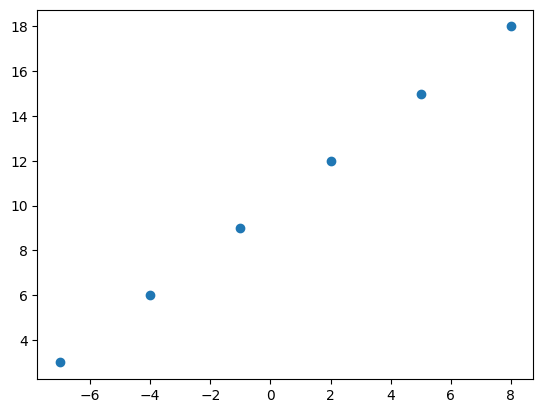

In [47]:
plt.scatter(x,y)

In [48]:
y == x+10

array([ True,  True,  True,  True,  True,  True])

Input and Output shapes

In [49]:
#create a demo tensor for our houseing prediction problem
house_info = tf.constant(["bedroom","bathroom","garage"])
house_price = tf.constant([939700])

In [50]:
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([939700], dtype=int32)>)

In [51]:
x[0], y[0]

(np.float64(-7.0), np.float64(3.0))

In [52]:
x[1], y[1]

(np.float64(-4.0), np.float64(6.0))

In [53]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape

((), ())

In [54]:
x[0].ndim

0

In [55]:
x[0] , y[0]

(np.float64(-7.0), np.float64(3.0))

In [56]:
#convert numpy arrays into tensors with dtype float 32
x = tf.cast(tf.constant(x), dtype=tf.float32)
y = tf.cast(tf.constant(y), dtype=tf.float32)

In [57]:
x , y


(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [58]:
input_shape = x[0].shape
output_shape = y[0].shape
input_shape, output_shape
#there is no shape as there is single value or scalar value

(TensorShape([]), TensorShape([]))

Steps in creating a model with TensorFlow

1. Creating a model - define the i/p and o/p layers , as well as the hidden layers of a deep learning model

2. Comppiling a model - define a loss fnc (in other words, the fnc which tells our model how wrong our model how wrong it is ) and optimizer (tells our model how to improve the patterns its learning ) and evaluation metrics (what we can use to interpret the performance of our model).

3. Fitting a model- letting the model try to find patterns between x & y (features and labels)

In [59]:
#Set random seed
tf.random.set_seed

#1. create a model using the Sequential API
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])# mae are short for mean absolute error
              #sgd is short for stochastic gradient descent

#3. Fit the model
model.fit(tf.expand_dims(x, axis=-1), y, epochs=5)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step - loss: 12.0223 - mae: 12.0223
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 11.9376 - mae: 11.9376
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 11.8529 - mae: 11.8529
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 11.7682 - mae: 11.7682
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 11.6835 - mae: 11.6835


In [60]:
#check out x and y
x , y

(<tf.Tensor: shape=(6,), dtype=float32, numpy=array([-7., -4., -1.,  2.,  5.,  8.], dtype=float32)>,
 <tf.Tensor: shape=(6,), dtype=float32, numpy=array([ 3.,  6.,  9., 12., 15., 18.], dtype=float32)>)

In [61]:
#Try add make prediction using our model
import numpy as np

y_pred = model.predict(np.array([[17.0]]))  # double brackets to make it 2D
print(y_pred)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
[[-12.692403]]


In [62]:
y_pred + 10   # mae: 9.8731 hence we our adding 10 to y predicted

array([[-2.6924028]], dtype=float32)

Improving our model

Steps we can improve our model, by altering the steps we took to create a model

1. Create a model -- here we might add more layersm increase the number of hidden units (all called neurons) within each of the hidden layers , change the activation fnc of each layer

2. "Compiling a model" -- here we might change the optimization fnc or perhaps the "learning rate" of the optimization fnc

3. "Fitting a model" -- here we might fit a model for more ""epochs"" (leave it training for longer) or on more data (give the model more example to learn from).

In [63]:
#higher the learning rate the more model pushes to improve at every step and lower the learning rate
# the model take lower steps to improve the model

In [64]:
import numpy as np

# If x was like this:
# x = [1.0, 2.0, 3.0, 4.0]

# Do this instead:
x = np.array([[1.0], [2.0], [3.0], [4.0]])
y = np.array([2.0, 4.0, 6.0, 8.0])  # keep y as 1D


In [65]:
#Lets rebuild our model

#1. Create the model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2. Compile the model
model.compile(loss=tf.keras.losses.mae,
              optimizer=tf.keras.optimizers.SGD(),
              metrics=["mae"])

#3. Fit the model
model.fit(x, y, epochs=100)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - loss: 3.7837 - mae: 3.7837
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 3.7112 - mae: 3.7112
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 3.6387 - mae: 3.6387
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 3.5662 - mae: 3.5662
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 3.4937 - mae: 3.4937
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 3.4212 - mae: 3.4212
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 3.3487 - mae: 3.3487
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 3.2762 - mae: 3.2762
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 3.2037 - mae: 3.2037
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 3.1312 - mae: 3.1312
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 3.0587 - mae: 3.0587
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 2.9862 - mae: 2.9862
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/st

In [66]:
#Remind ourselves of the data
x,y


(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [67]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


array([[32.2655]], dtype=float32)

In [68]:
#Let's see if we can make another to improve our model

#create the model (this time with an extra hidden layer with 100 hidden units)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(50,activation= None),
    tf.keras.layers.Dense(1)
])

#2 . Compile the model
model.compile(loss ="mae",
              optimizer= tf.keras.optimizers.Adam(learning_rate=0.001),
              metrics=["mae"])


#fit the model
model.fit(x,y,epochs=100)


Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 5.7319 - mae: 5.7319
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.6801 - mae: 5.6801
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 5.6282 - mae: 5.6282
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 5.5764 - mae: 5.5764
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 5.5246 - mae: 5.5246
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 5.4727 - mae: 5.4727
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 5.4209 - mae: 5.4209
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 5.3690 - mae: 5.3690
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - loss: 5.3171 - mae: 5.3171
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 5.2652 - mae: 5.2652
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 5.2133 - mae: 5.2133
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 5.1614 - mae: 5.1614
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step 

In [69]:
#Remind ourselves of the data
x,y

(array([[1.],
        [2.],
        [3.],
        [4.]]),
 array([2., 4., 6., 8.]))

In [70]:
#let 's see if our model's prediction has improved
model.predict(np.array([[17.0]]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


array([[27.486403]], dtype=float32)

Common Ways To Improve the Deep Model

1. Adding The Layers
2. Increase the number of hidden units
3. Change the activation fnc
4. Change the optimization fnc
5. Change the learning rate(potentially the most imp hyperparameter of many diff neural networks)
6. Fitting more data
7. Fitting for longer



Evaluating a Model

In practice, a typical workflow you will go through while building a neural networks is:

Build a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it -> tweak a model -> fit it -> evaluate it....

When it comes to evaluation.... there are 3 words you should memorize:

"Visualize, Visualize , Visualize"

It's good idea to visualize:

* the data we are working with? What does it look like ?
* The model itself - What does our model look like?
* The training of a model how does a model perform while learn
* The prediction of a model how does a prediction of a model line up against the ground truth ( the original labels)?

In [71]:
#Make a bigger dataset  most probably for a good prediction or training

x  = tf.range(-100,100,4)
x

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
        -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
        -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
         32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
         76,   80,   84,   88,   92,   96], dtype=int32)>

In [72]:
#we want our model to learn this formula
y = x + 10
y

<tf.Tensor: shape=(50,), dtype=int32, numpy=
array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
       -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
        14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
        66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>

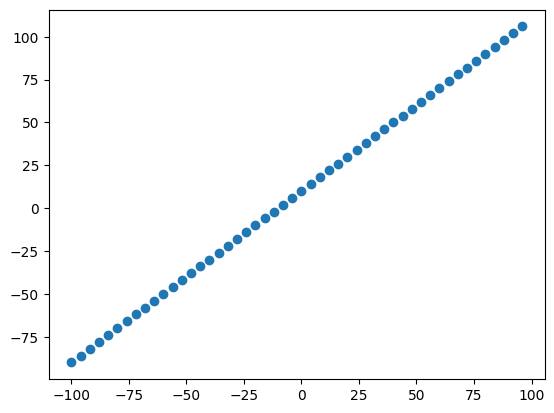

In [73]:
#visulaize our data
import matplotlib.pyplot as plt
plt.scatter(x,y)


# There are 3 sets ..........

**Training set** :- The model learn from this data , typically contains 80% of the the total dataset available

**Validation dataset** :- The model gets tuned on this data , typically contains 10%-15% of the the total dataset available

**Testing dataset** :- The model gets test on this data , typically contains 10%-15% of the the total dataset available

In [74]:
len(x)

50

In [75]:
#Split the data into training and testing dataset

x_train = x[:40]#80% of the data is been given for training from 1-40     #first 40 are training samples
x_test = x[40:]#20% of the data is been given for testing from 41-50

y_train = x[:40]
y_test = x[40:]

In [76]:
len(x_test), len(x_train), len(y_test), len(y_train)

(10, 40, 10, 40)

visualize the data the test and train split

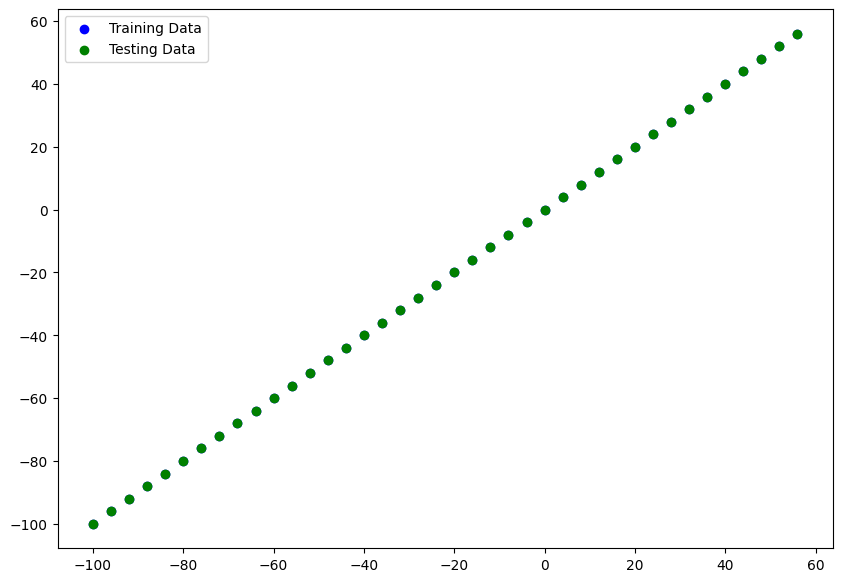

In [77]:
plt.figure(figsize=(10,7))
#now plot training data with blue
plt.scatter(x_train,y_train, c='b', label='Training Data')
#now plot testing data with green
plt.scatter(x_train,y_train, c='g', label='Testing Data')

plt.legend()

In [78]:
#lets have a look how to build a neural network

#1.create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1)
])

#2.Compile the model

model.compile(optimizer=tf.keras.optimizers.SGD(), loss=tf.keras.losses.mae, metrics=["mae"])

#3. fit the model


In [79]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [80]:
#Lets create a model which build automatically after defining the input_shape
tf.random.set_seed(42)


#1.create a model (same as above)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(1 , input_shape=[1])
])
                                                            #a fully connected layer is same as Dense layer
#2.Compile the model (same as above)

model.compile(optimizer=tf.keras.optimizers.SGD(), loss=tf.keras.losses.mae, metrics=["mae"])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)